In [91]:
import os
import subprocess
import baltic as bt
import pandas as pd
import json
from io import StringIO as sio
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.patheffects as path_effects
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from collections import Counter
from Bio import SeqIO
from sklearn.manifold import TSNE
from matplotlib.patches import ConnectionPatch



Tree height: 0.207000
Tree length: 4.017782
annotations present

Numbers of objects in tree: 1431 (678 nodes and 753 leaves)


Tree height: 0.207000
Tree length: 4.017782
annotations present

Numbers of objects in tree: 1431 (678 nodes and 753 leaves)



/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_18288/3184828764.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap('tab20', len(unique_clades))


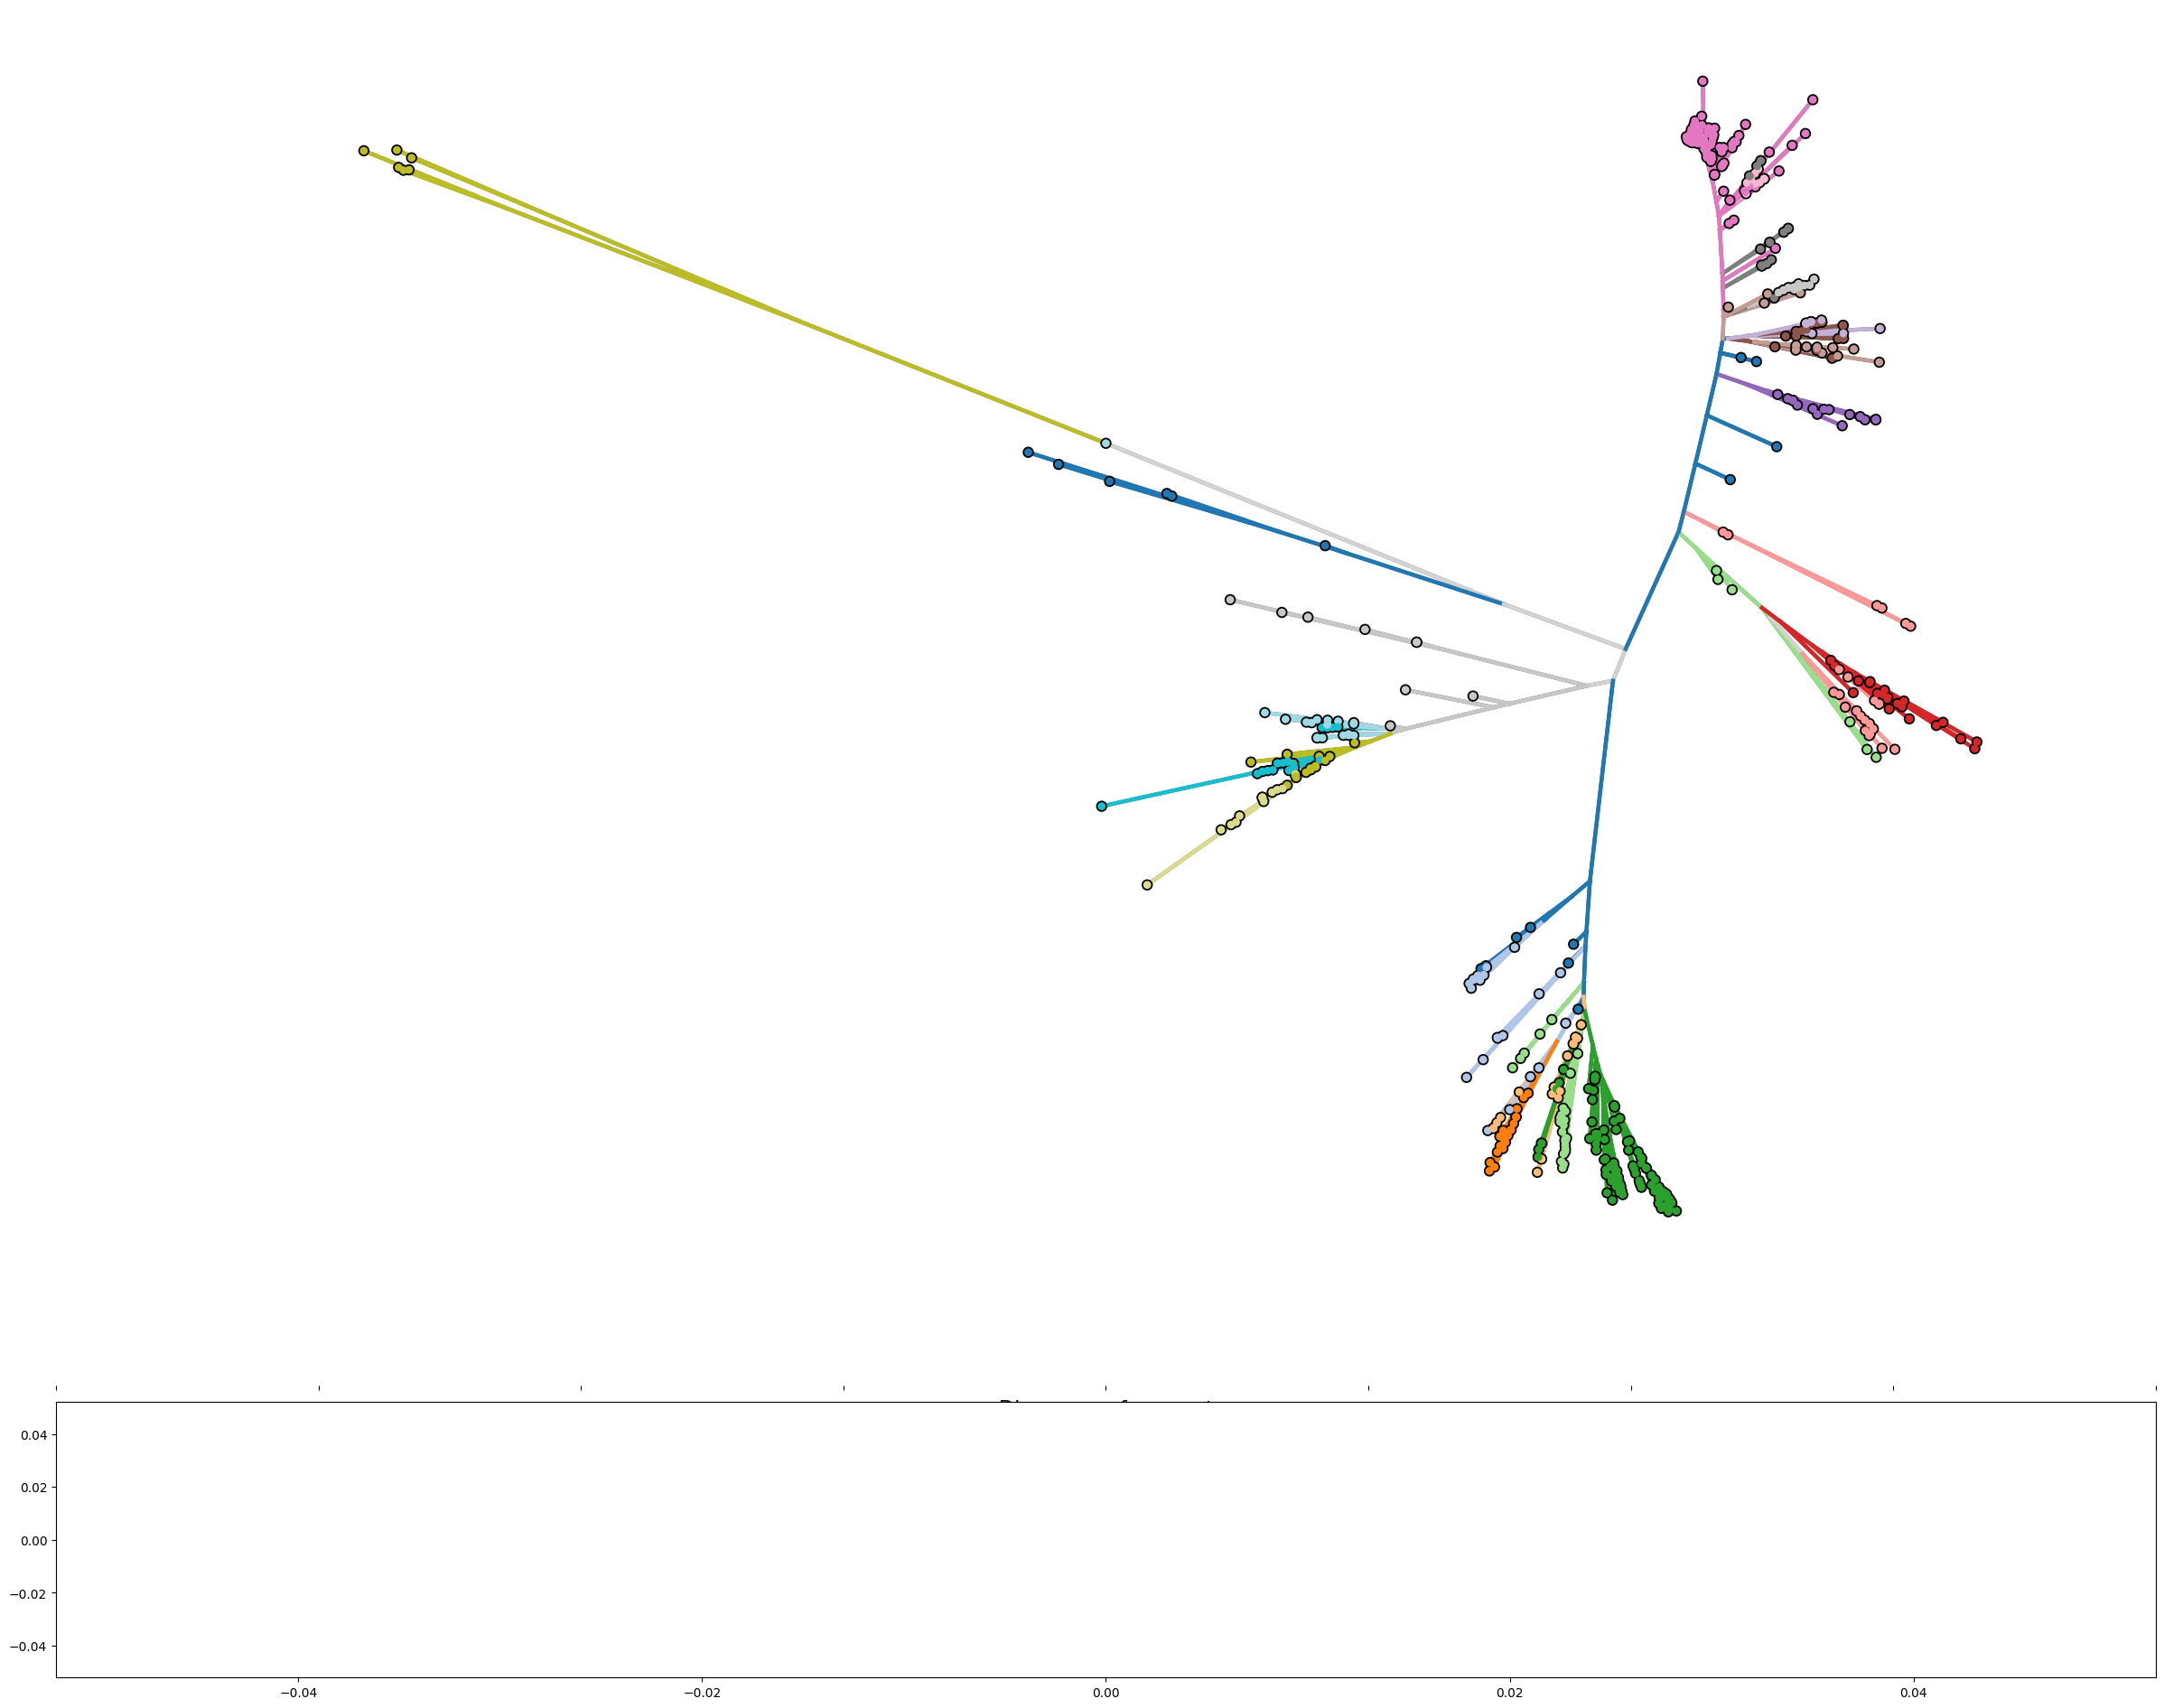

In [44]:
D2_nextstrain = '../Data/D2/Col_only/nextclade.auspice.json'

def prune(node, thresh=0.15):
    # only operate on dict-nodes
    if not isinstance(node, dict):
        return node
    # get the divergence (a float) for *this* branch
    div = node.get('node_attrs', {}) .get('div')
    if div is not None and div > thresh:
        return None
    # otherwise prune children
    if 'children' in node:
        kept = []
        for child in node['children']:
            pc = prune(child, thresh)
            if pc is not None:
                kept.append(pc)
        node['children'] = kept
    return node

# 1) Read the file
with open(D2_nextstrain, 'r') as fh:
    nx_json = json.load(fh)


# 2) Tell baltic to use 'div' as the node height
json_translation = {
    'absoluteTime': lambda node: node.traits['node_attrs']['div'],
    'name': 'name'
}

# 3) Load into baltic
ll, meta = bt.loadJSON(nx_json, json_translation=json_translation)

# 1) Create a blank figure
fig = plt.figure(figsize=(30, 24), facecolor='w')

# 2) Make a 2×1 GridSpec: row 0 for tree, row 1 for t-SNE
#    Give the tree 5× the height of the bottom panel
gs = gridspec.GridSpec(
    nrows=2,
    ncols=1,
    height_ratios=[5, 1],
    hspace=0.02
)

# 3) Grab the axes from that grid
ax_tree = fig.add_subplot(gs[0, 0])   # top (tree)
ax_tsne = fig.add_subplot(gs[1, 0])   # bottom (t-SNE)

# 4) (optional) if you want the bottom to have some padding/margins
ax_tsne.margins(x=0.02, y=0.02)


L=len(list(filter(lambda k: k.branchType=='leaf',ll.Objects)))

clade_list = [
    k.traits['node_attrs']
      .get('clade_membership', {})
      .get('value')
    for k in ll.Objects if k.is_leaf()
]

# create a unique sorted list and assign colors from tab20
unique_clades = sorted({c for c in clade_list if c is not None})
palette = cm.get_cmap('tab20', len(unique_clades))
clade_color_map = {
    clade: mcolors.to_hex(palette(i))
    for i, clade in enumerate(unique_clades)
}

# register this map under 'clade_membership'
ll.cmap['clade_membership'] = clade_color_map

clade_counts = Counter(
    node.traits['node_attrs']['clade_membership']['value']
    for node in ll.Objects if node.is_leaf()
)
filtered = {clade: cnt for clade, cnt in clade_counts.items() if cnt >= 50}
clades, counts = zip(*sorted(filtered.items(), key=lambda x: x[1], reverse=True))
colors = [ll.cmap['clade_membership'][c] for c in clades]

# colour function using the newly registered map
def c_func(node):
    clade = node.traits['node_attrs'] \
               .get('clade_membership', {}) \
               .get('value')
    return ll.cmap['clade_membership'].get(clade, 'lightgrey')


x_attr = lambda k: k.absoluteTime
b_func=lambda k: 2+10.0*len(k.leaves)/float(L) if k.branchType=='node' else 2

# plotting
ll.treeStats()
ll.drawUnrooted(rotate=0.45)

ll.plotTree(ax=ax_tree,
            colour=c_func,
            zorder=10,
            width=3.2,
            connection_type='direct')

ll.plotTree(ax=ax_tree,
            colour='#3A3B3C',
            zorder=8,
            width=3,
            connection_type='direct')

ll.plotPoints(ax=ax_tree,colour=c_func, size = 40, zorder=20)



for loc in ['left', 'right', 'top', 'bottom']:
    ax_tree.spines[loc].set_visible(False)

ax_tree.tick_params(axis='y', size=0)
ax_tree.tick_params(axis='x', labelsize=16)
ax_tree.set_xlabel('Divergence from root', fontsize=16)
ax_tree.set_xlim(-0.2, 0.2)
ax_tree.set_ylim(-0.13, 0.06)
ax_tree.set_yticklabels([])
ax_tree.set_xticklabels([])



#
#plt.savefig('../Figures/Supplementary/Dengue2_global.jpeg', dpi = 1200, bbox_inches='tight')
plt.show()


Tree height: 0.207000
Tree length: 4.017782
annotations present

Numbers of objects in tree: 1431 (678 nodes and 753 leaves)



/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_18288/2525837895.py:119: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab20", len(unique_clades))



Tree height: 0.207000
Tree length: 4.017782
annotations present

Numbers of objects in tree: 1431 (678 nodes and 753 leaves)



/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_18288/2525837895.py:313: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


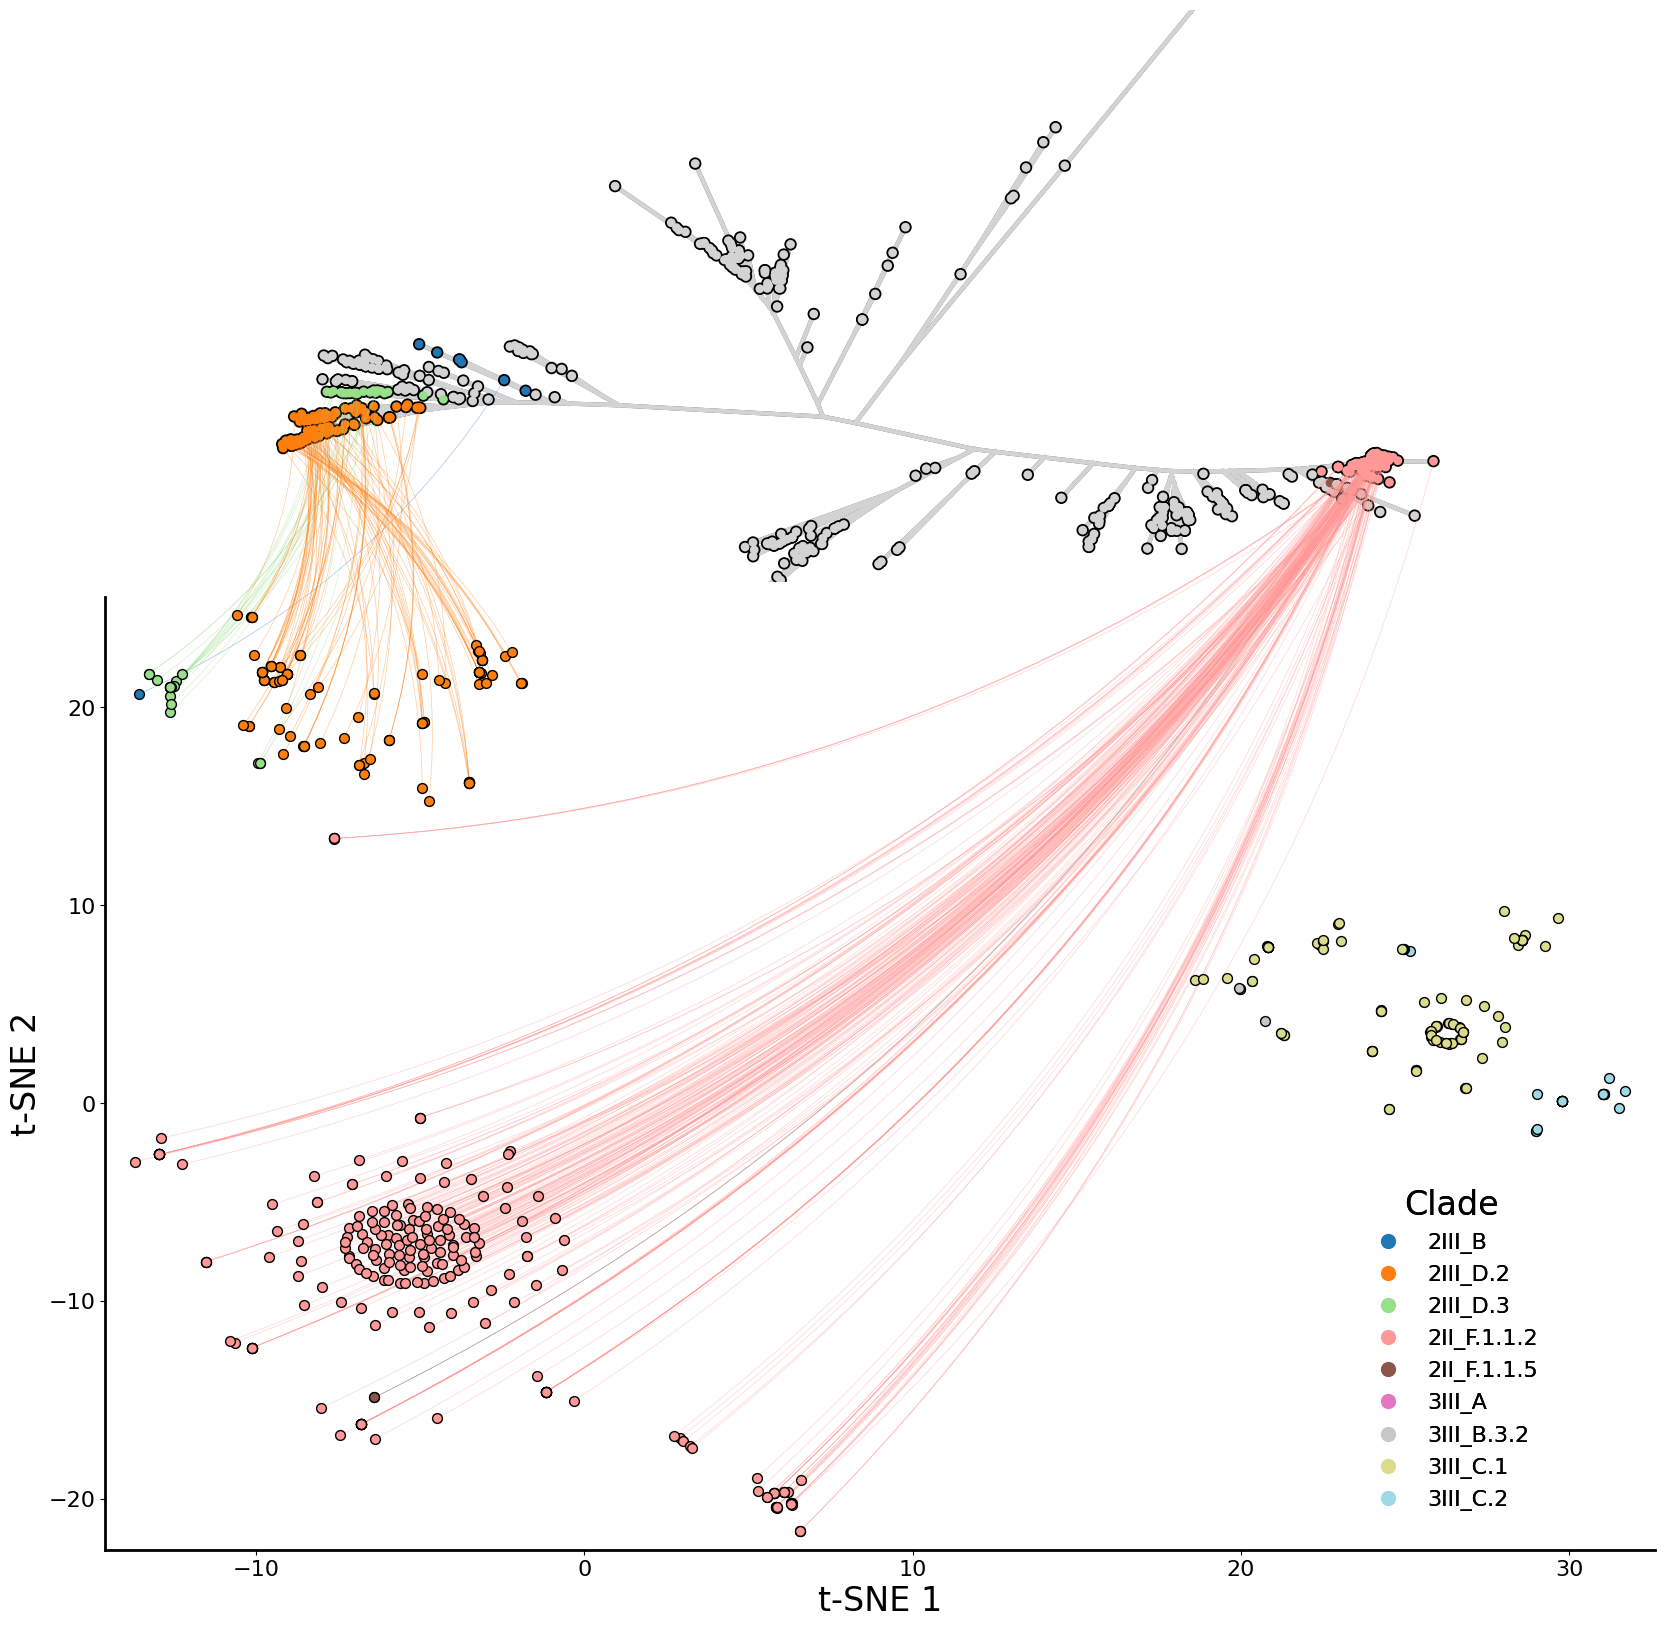

In [142]:

# —————————————————————————————————————————————————————————
# 1) Prune + load your Nextstrain JSON into baltic
# —————————————————————————————————————————————————————————
D2_nextstrain = '../Data/D2/Col_only/nextclade.auspice.json'

def prune(node, thresh=0.15):
    # only operate on dict-nodes
    if not isinstance(node, dict):
        return node

    # --- 1) If this subtree contains ANY "2V-A" leaf, drop it entirely ---
    def contains_2V_A(sub):
        # check this node
        if sub.get('node_attrs', {}) \
               .get('clade_membership', {}) \
               .get('value') == "2V-A":
            return True
        # recurse through children
        for child in sub.get('children', []):
            if contains_2V_A(child):
                return True
        return False

    if contains_2V_A(node):
        return None

    # --- 2) Now your original divergence filter ---
    div = node.get('node_attrs', {}).get('div')
    if div is not None and div > thresh:
        return None

    # --- 3) Recurse into children and keep only survivors ---
    if 'children' in node:
        kept = []
        for child in node['children']:
            pr = prune(child, thresh)
            if pr is not None:
                kept.append(pr)
        node['children'] = kept

        # 4) If no children remain, drop this node too
        if not kept:
            return None

    return node

# 1) Read the file
with open(D2_nextstrain, 'r') as fh:
    nx_json = json.load(fh)


# 2) Tell baltic to use 'div' as the node height
json_translation = {
    'absoluteTime': lambda node: node.traits['node_attrs']['div'],
    'name': 'name'
}

# 3) Load into baltic
ll, meta = bt.loadJSON(nx_json, json_translation=json_translation)

# ll = ll.collapseBranches(
#     collapseIf=lambda node: node.traits['node_attrs']['div'] > 0.2,
#     designated_nodes=[],
#     verbose=True
# )


# ————————————————————————————————————————————————
# 2) Load & combine your DENV-2 and DENV-3 sequences + metadata
# ————————————————————————————————————————————————
# 2a) DENV-2
records2 = list(SeqIO.parse("../Data/D2/Col_only/nextclade.cds_translation.E.fasta", "fasta"))
names2   = [r.id for r in records2]
seqs2    = np.array([list(str(r.seq)) for r in records2])
meta2    = pd.read_csv(
    "../Data/D2/Col_only/nextclade.csv",
    usecols=["seqName","clade"], sep=";",
    dtype=str, on_bad_lines="skip"
)
meta2["serotype"] = "DENV2"

# 2b) DENV-3 (Colombian only)
records3 = list(SeqIO.parse("../Data/D3/D3gisaid_arbo_2025_04_24_18/nextclade.cds_translation_Colombia.E.fasta", "fasta"))
names3   = [r.id for r in records3]
seqs3    = np.array([list(str(r.seq)) for r in records3])
meta3    = pd.read_csv(
    "../Data/D3/D3gisaid_arbo_2025_04_24_18/nextclade.csv",
    usecols=["seqName","clade"], sep=";",
    dtype=str, on_bad_lines="skip"
)
# filter to Colombian seqNames
meta3 = meta3[meta3["seqName"].str.contains("Colombia")].copy()
meta3["serotype"] = "DENV3"

# 2c) combine
names    = names2 + names3
def pad_to(seqs, L):
    n, l = seqs.shape
    if l < L:
        pad = np.full((n, L-l), "-", dtype=seqs.dtype)
        return np.hstack([seqs, pad])
    return seqs

L_max  = max(seqs2.shape[1], seqs3.shape[1])
seqs2  = pad_to(seqs2, L_max)
seqs3  = pad_to(seqs3, L_max)
seqs   = np.vstack([seqs2, seqs3])

metadata = pd.concat([meta2, meta3], ignore_index=True).set_index("seqName")


# ————————————————————————————————————————————————
# 3) Build a single clade→colour map (used by tree & t-SNE)
# ————————————————————————————————————————————————
unique_clades = sorted(
    c for c in metadata["clade"].unique()
    if pd.notnull(c)
)
palette = cm.get_cmap("tab20", len(unique_clades))
clade_color_map = {
    clade: mcolors.to_hex(palette(i))
    for i, clade in enumerate(unique_clades)
}

# register in baltic so `plotTree(..., colour=c_func)` can use it
ll.cmap["clade_membership"] = clade_color_map


# ————————————————————————————————————————————————————————
# 4) Compute pairwise distances & run t-SNE
# ————————————————————————————————————————————————————————
n = len(names)
D = np.zeros((n,n))
for i in range(n):
    for j in range(i+1, n):
        s1, s2 = seqs[i], seqs[j]
        mask   = (s1 != "-") & (s2 != "-")
        D[i,j] = D[j,i] = np.sum(s1[mask] != s2[mask]) / np.sum(mask)

tsne = TSNE(
    n_components=2,
    metric="precomputed",
    init="random",
    perplexity=30,
    random_state=0
)
coords = tsne.fit_transform(D)


# ————————————————————————————————————————————————
# 5) Set up figure: unrooted tree on top, t-SNE below
# ————————————————————————————————————————————————
fig = plt.figure(figsize=(20, 20), facecolor="w")
gs  = gridspec.GridSpec(2, 1, height_ratios=[0.6, 1], hspace=0.02, width_ratios=[1])

ax_tree = fig.add_subplot(gs[0, 0])
ax_tsne = fig.add_subplot(gs[1, 0])
ax_tsne.margins(x=0.02, y=0.02)


# ————————————————————————————————————————————————
# 6) Draw the unrooted tree (coloured by clade)
# ————————————————————————————————————————————————
ll.treeStats()
plt.sca(ax_tree)    # make ax_tree the current axes


# unrooted layout
ll.sortBranches(descending=True)
ll.drawUnrooted(rotate=0.2)

# 1) coloured branches
c_func = lambda node: clade_color_map.get(
    node.traits["node_attrs"]
        .get("clade_membership", {})
        .get("value"),
    "lightgrey"
)

c_func_branch = lambda node: clade_color_map.get(
    node.traits["branch_attrs"]
        .get("clade_membership", {})
        .get("value"),
    "lightgrey"
)


ll.plotTree(
    ax=ax_tree,
    colour=c_func_branch,
    zorder=10,
    width=3.2,
    connection_type="direct"
)
# 2) darker under‐plot for depth contrast
ll.plotTree(
    ax=ax_tree,
    colour="#3A3B3C",
    zorder=8,
    width=3,
    connection_type="direct"
)
# 3) leaf points
ll.plotPoints(
    ax=ax_tree,
    colour=c_func,
    size=40,
    zorder=20
)

# fit & clean

pad = 0.05
ax_tree.set_xlim(-0.13, 0.08)
ax_tree.set_ylim(-0.16, 0.06)

for sp in ax_tree.spines.values():
    sp.set_visible(False)
ax_tree.set_xticks([])
ax_tree.set_yticks([])


# ————————————————————————————————————————————————
# 7) Plot the t-SNE (same colours by clade, different markers by serotype)
# ————————————————————————————————————————————————
marker_map = {"DENV2": "o", "DENV3": "o"}

for idx, name in enumerate(names):
    ser   = metadata.at[name, "serotype"]
    clade = metadata.at[name, "clade"]
    col   = clade_color_map.get(clade, "#CCCCCC")
    ax_tsne.scatter(
        coords[idx,0],
        coords[idx,1],
        c=col,
        marker=marker_map[ser],
        edgecolor="k",
        s=50,
        alpha=1
    )

for leaf in ll.getExternal():
    nm = leaf.name
    parts = nm.split('/')
    # only connect Colombian sequences
    if len(parts) >= 2 and parts[1] == "Colombia":
        # 1) get the correct colour from your clade map
        clade = metadata.loc[nm, "clade"]
        col   = clade_color_map.get(clade, "#CCCCCC")

        # 2) tree coords (unrooted layout)
        x_tree, y_tree = leaf.x, leaf.y

        # 3) t-SNE coords
        try:
            idx = names.index(nm)
        except ValueError:
            continue
        x_tsne, y_tsne = coords[idx]

        # 4) draw a curved connection in that colour
        con = ConnectionPatch(
            xyA=(x_tsne, y_tsne),
            coordsA=ax_tsne.transData,
            xyB=(x_tree, y_tree),
            coordsB=ax_tree.transData,
            linestyle='-',
            color=col,
            linewidth=0.5,
            alpha=0.4,
            connectionstyle='arc3,rad=0.15',
            zorder=0
        )
        # add to one of the axes (it will draw across both)
        ax_tsne.add_artist(con)

plt.draw()


# legends
from matplotlib.lines import Line2D

# a) clade colours
clade_handles = [
    Line2D([0],[0],
           marker="o", color="w",
           label=cl,
           markerfacecolor=clade_color_map[cl],
           markersize=8)
    for cl in unique_clades
]
leg1 = ax_tsne.legend(
    handles=clade_handles,
    title="Clade",
    bbox_to_anchor=(0.8,0.40),
    loc="upper left",
    frameon=False,
    fontsize=16,
    title_fontsize=24,
    markerscale=1.5
)

ax_tsne.add_artist(leg1)
# clean axes
ax_tsne.set_xlabel("t-SNE 1", fontsize=24)
ax_tsne.set_ylabel("t-SNE 2", fontsize=24)
ax_tsne.tick_params(axis='both', labelsize=16)
for spine in ax_tsne.spines.values():
    spine.set_linewidth(2)
ax_tsne.spines['right'].set_visible(False)
ax_tsne.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig("../Figures/Dengue2_3_tree_tsne.jpeg", dpi=1200, bbox_inches="tight")
plt.show()